# fio DFS Heatmap Sweep — iodepth × block size

Analyzes results from a single-job sweep of `(iodepth, block_size)` pairs with the DAOS DFS ioengine.  
Produces heatmaps of **throughput (BW, IOPS)** and **latency** as functions of both dimensions.

In [1]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = Path(".")

BS_ORDER   = ["4k", "16k", "1m", "2m", "4m"]
IOD_ORDER  = [4, 8, 16, 32, 64, 128, 256]

In [2]:
def bs_to_bytes(bs: str) -> int:
    bs = bs.lower()
    if bs.endswith("k"):
        return int(bs[:-1]) * 1024
    if bs.endswith("m"):
        return int(bs[:-1]) * 1024 ** 2
    return int(bs)

def parse_file(fpath: Path) -> dict:
    m = re.search(r"fio_\w+_bs(\w+?)_nj(\d+)_iod(\d+)_", fpath.name)
    bs, nj, iod = m.group(1), int(m.group(2)), int(m.group(3))

    with open(fpath) as f:
        d = json.load(f)

    job = d["jobs"][0]
    # pick the active direction (read or write)
    io = job["read"] if job["read"]["io_bytes"] > 0 else job["write"]
    clat = io["clat_ns"]
    lat  = io["lat_ns"]
    cp   = clat["percentile"]

    def ms(v): return v / 1e6

    return dict(
        bs             = bs,
        iodepth        = iod,
        numjobs        = nj,
        bw_GiBs        = io["bw_bytes"] / 1024**3,
        iops           = io["iops"],
        lat_min_ms     = ms(lat["min"]),
        lat_mean_ms    = ms(lat["mean"]),
        lat_max_ms     = ms(lat["max"]),
        clat_mean_ms   = ms(clat["mean"]),
        clat_p50_ms    = ms(cp["50.000000"]),
        clat_p90_ms    = ms(cp["90.000000"]),
        clat_p99_ms    = ms(cp["99.000000"]),
        clat_p99_9_ms  = ms(cp["99.900000"]),
        clat_p99_99_ms = ms(cp["99.990000"]),
    )

files = sorted(RESULTS_DIR.glob("*.json"))
df = pd.DataFrame([parse_file(f) for f in files])

df["bs_bytes"] = df["bs"].apply(bs_to_bytes)
df["bs"]       = pd.Categorical(df["bs"],      categories=BS_ORDER,  ordered=True)
df["iodepth"]  = pd.Categorical(df["iodepth"], categories=IOD_ORDER, ordered=True)
df = df.sort_values(["bs_bytes", "iodepth"]).reset_index(drop=True)

print(f"Loaded {len(df)} result files")
df

Loaded 35 result files


,bs,iodepth,numjobs,bw_GiBs,iops,lat_min_ms,lat_mean_ms,lat_max_ms,clat_mean_ms,clat_p50_ms,clat_p90_ms,clat_p99_ms,clat_p99_9_ms,clat_p99_99_ms,bs_bytes
0,4k,4,1,0.099213,26008.066532,0.083451,0.153463,12.925588,0.149381,0.136192,0.220160,0.232448,0.264192,8.716288,4096
1,4k,8,1,0.141088,36985.483575,0.032731,0.215977,12.941608,0.211776,0.201728,0.301056,0.354304,0.452608,9.764864,4096
2,4k,16,1,0.175591,46030.182830,0.034671,0.347251,14.526919,0.343246,0.358400,0.497664,0.593920,0.880640,10.158080,4096
3,4k,32,1,0.271342,71130.764487,0.085012,0.449502,16.611911,0.445219,0.419840,0.724992,0.864256,1.171456,11.337728,4096
4,4k,64,1,0.305579,80105.729809,0.088992,0.798557,13.671313,0.795914,0.790528,1.122304,1.236992,5.668864,11.730944,4096
5,4k,128,1,0.399531,104734.725509,0.406218,1.221705,29.972118,1.219449,1.204224,1.548288,1.695744,8.355840,13.303808,4096
6,4k,256,1,0.389781,102178.657734,1.763775,2.504612,16.723402,2.502368,2.473984,2.801664,3.031040,12.517376,15.138816,4096
7,16k,4,1,0.246915,16181.830303,0.135972,0.246792,12.977779,0.241115,0.236544,0.288768,0.325632,0.399360,9.240576,16384
8,16k,8,1,0.433686,28422.042966,0.146113,0.281078,13.281739,0.275519,0.264192,0.358400,0.423936,0.493568,10.289152,16384
9,16k,16,1,0.820782,53790.736821,0.133543,0.297065,13.388545,0.291948,0.288768,0.362496,0.419840,0.569344,9.502720,16384


## Throughput Heatmaps

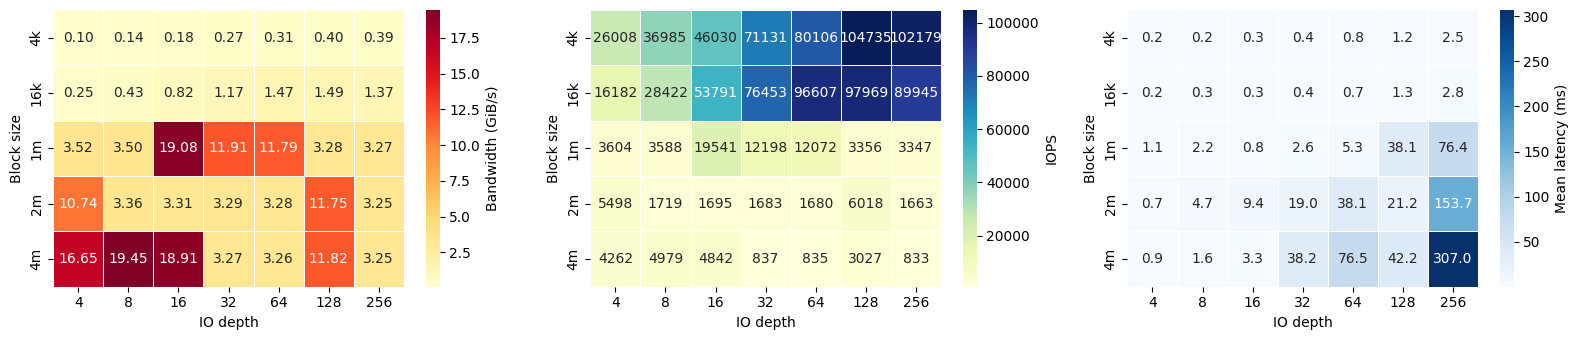

In [3]:
def pivot(metric):
    return df.pivot(index="bs", columns="iodepth", values=metric).loc[BS_ORDER, IOD_ORDER]

fig, axes = plt.subplots(1, 3, figsize=(16, 3.5))

specs = [
    ("bw_GiBs", "Bandwidth (GiB/s)", ".2f", "YlOrRd"),
    ("iops",    "IOPS",              ".0f", "YlGnBu"),
    ("lat_mean_ms",    "Mean latency (ms)", ".1f", "Blues"),
]
for ax, (metric, label, fmt, cmap) in zip(axes, specs):
    sns.heatmap(
        pivot(metric), ax=ax, cmap=cmap, fmt=fmt, annot=True,
        linewidths=0.5, 
        cbar_kws={"label": label},
    )
    ax.set_xlabel("IO depth")
    ax.set_ylabel("Block size")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "seq-red_heatmap.pdf", bbox_inches="tight", dpi=150)
plt.show()

## Latency Heatmaps

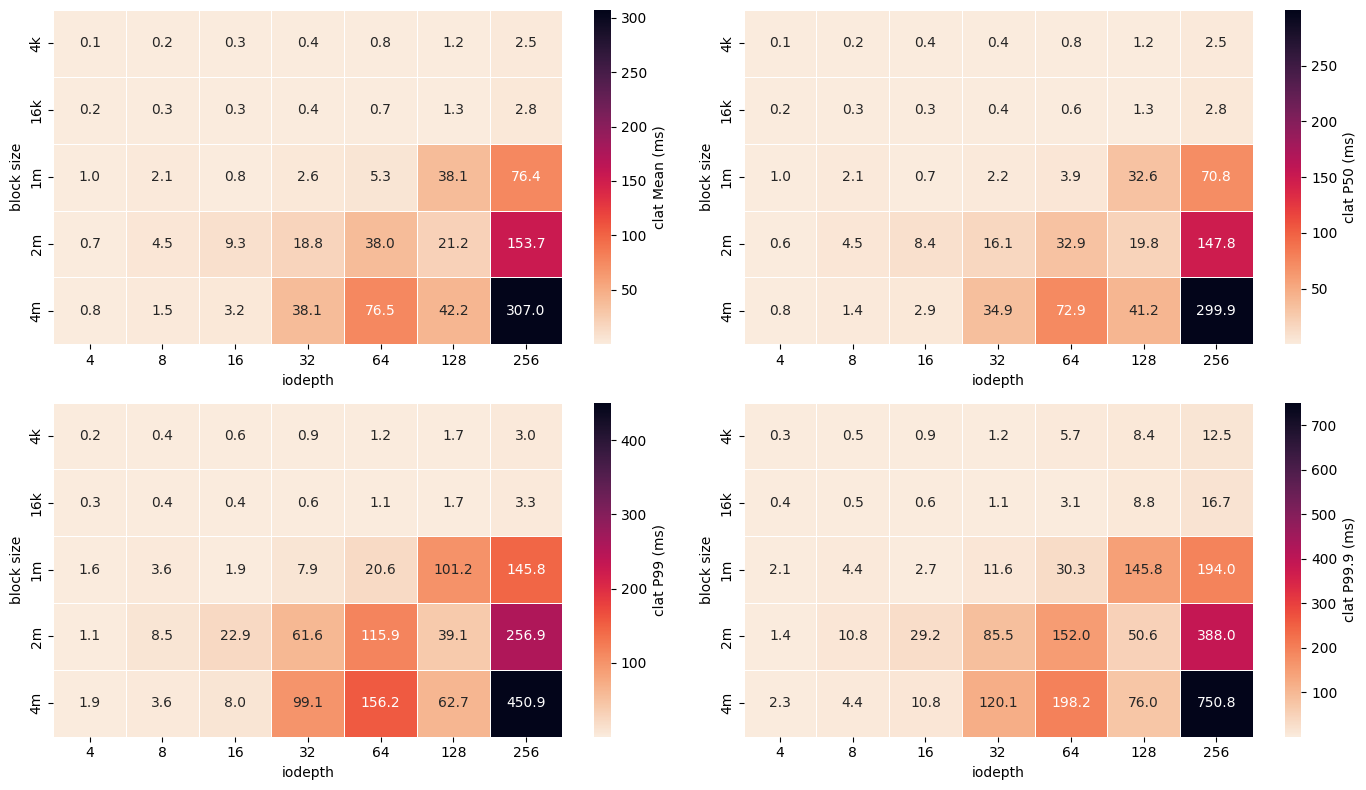

In [4]:
lat_metrics = [
    ("clat_mean_ms",   "clat Mean (ms)"),
    ("clat_p50_ms",    "clat P50 (ms)"),
    ("clat_p99_ms",    "clat P99 (ms)"),
    ("clat_p99_9_ms",  "clat P99.9 (ms)"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (metric, label) in zip(axes.flat, lat_metrics):
    p = pivot(metric)
    sns.heatmap(
        p, ax=ax, cmap="rocket_r", annot=True, fmt=".1f",
        linewidths=0.5, cbar_kws={"label": label},
    )
    ax.set_xlabel("iodepth")
    ax.set_ylabel("block size")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "heatmap_latency.pdf", bbox_inches="tight", dpi=150)
plt.show()

## Tail Latency Detail — P99 & P99.9

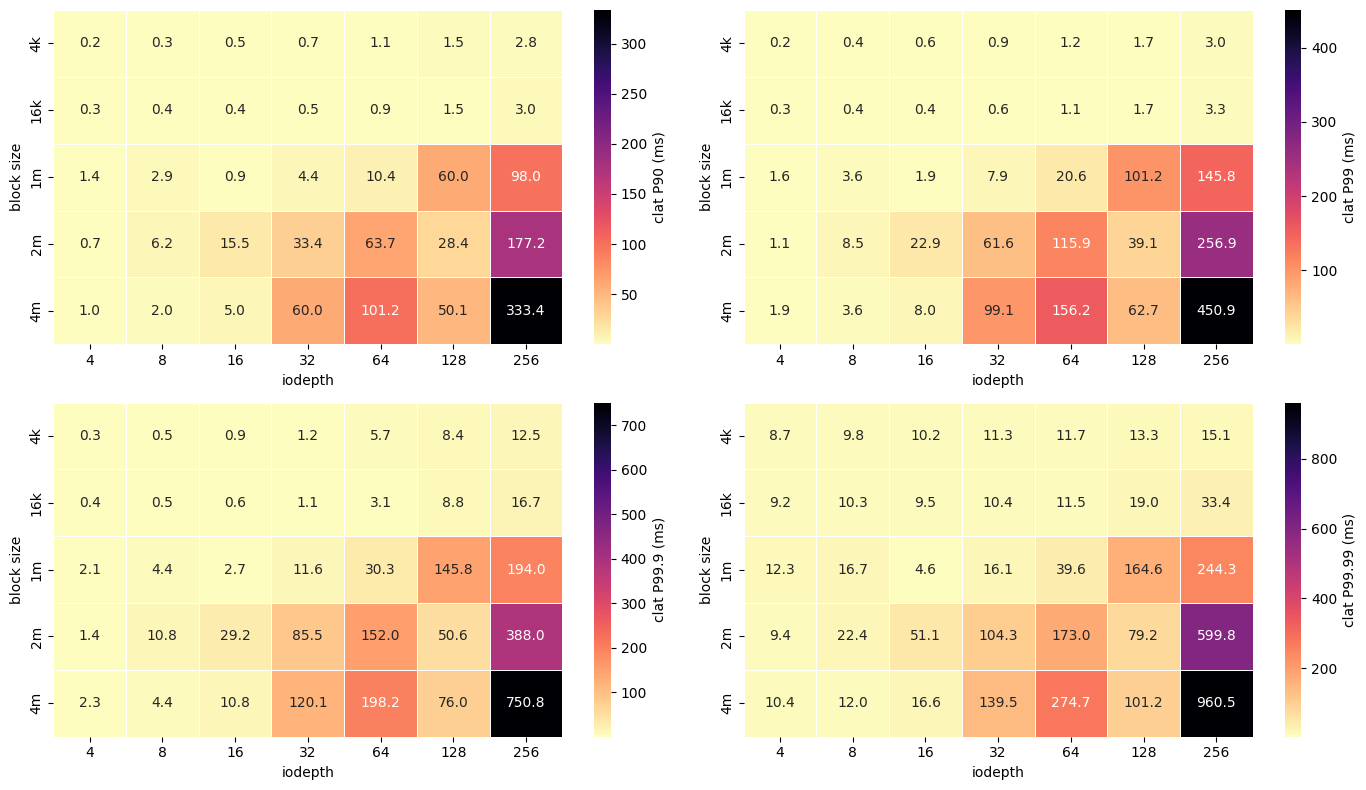

In [5]:
tail_metrics = [
    ("clat_p90_ms",    "clat P90 (ms)"),
    ("clat_p99_ms",    "clat P99 (ms)"),
    ("clat_p99_9_ms",  "clat P99.9 (ms)"),
    ("clat_p99_99_ms", "clat P99.99 (ms)"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (metric, label) in zip(axes.flat, tail_metrics):
    p = pivot(metric)
    sns.heatmap(
        p, ax=ax, cmap="magma_r", annot=True, fmt=".1f",
        linewidths=0.5, cbar_kws={"label": label},
    )
    ax.set_xlabel("iodepth")
    ax.set_ylabel("block size")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "heatmap_tail_latency.pdf", bbox_inches="tight", dpi=150)
plt.show()

## Total Latency — Min / Mean / Max

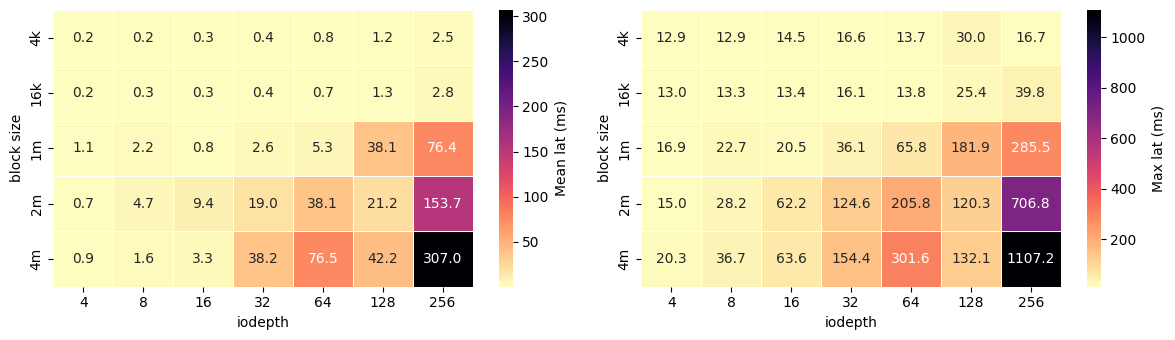

In [6]:
minmeanmax_metrics = [
    # ("lat_min_ms",  "Min lat (ms)"),
    ("lat_mean_ms", "Mean lat (ms)"),
    ("lat_max_ms",  "Max lat (ms)"),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

for ax, (metric, label) in zip(axes, minmeanmax_metrics):
    p = pivot(metric)
    sns.heatmap(
        p, ax=ax, cmap="magma_r", annot=True, fmt=".1f",
        linewidths=0.5, cbar_kws={"label": label},
    )
    ax.set_xlabel("iodepth")
    ax.set_ylabel("block size")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "heatmap_lat_mean_max.pdf", bbox_inches="tight", dpi=150)
plt.show()

## Findings & Conclusion

**Workload:** `seq_read`, single job (`numjobs=1`), DAOS DFS ioengine, 60 s per run.
Axes: block size ∈ {4k, 16k, 1m, 2m, 4m} × iodepth ∈ {4, 8, 16, 32, 64, 128, 256}.

---

### Finding 1 — Small blocks scale predictably; large blocks do not

For **4k and 16k**, IOPS increases near-linearly with iodepth up to saturation (~iod=128) and latency tracks Little's Law (`lat ≈ iodepth / IOPS`) throughout. The behavior is smooth and tunable.

For **1m, 2m, 4m**, bandwidth does not increase monotonically with iodepth. It jumps between three discrete levels:

| Regime | BW | Example configs |
|--------|----|-----------------|
| Floor | ~3.3 GiB/s | 1m iod≤8 or ≥128 · 2m iod=8–64 or 256 · 4m iod≥32 (except 128) |
| Intermediate | ~11.8 GiB/s | 1m iod=32,64 · 2m iod=4,128 · 4m iod=128 |
| Peak | ~16.7–19.5 GiB/s | 1m iod=16 · 4m iod=4,8,16 |

The floor : intermediate : peak ratio (~1 : 3.6 : 5.9) is consistent with a fixed number of DAOS storage targets that are only fully utilized when iodepth and block size together generate enough non-conflicting concurrent IOs to stripe across all of them. When the combination misses the internal stripe or shard boundaries, IOs serialize onto fewer targets and throughput collapses.

---

### Finding 2 — BW collapse causes a disproportionate latency explosion

When BW drops to the floor, mean latency increases by far more than the BW ratio alone would predict — the queue fills with IOs waiting on serialized targets:

| Config | BW | Mean lat | P99 lat | P99.99 lat |
|--------|----|----------|---------|------------|
| 4m, iod=8 | 19.5 GiB/s | 1.6 ms | 3.6 ms | 12 ms |
| 4m, iod=32 | 3.3 GiB/s | 38 ms | 99 ms | 139 ms |
| 4m, iod=256 | 3.3 GiB/s | 307 ms | 451 ms | 960 ms |

A 6× BW drop at 4m produces a ~190× mean latency increase. The worst case (4m, iod=256) is near a full second at P99.99.

---

### Finding 3 — 2m block size is pathological at most iodepths

The 2m block never reaches the peak regime at any tested iodepth and its BW is the least predictable — high at iod=4 and iod=128, floor everywhere else. This oscillatory pattern suggests 2m aligns unfavorably with DAOS object/EC stripe boundaries at most queue depths and should be avoided for sequential reads.

---

### Finding 4 — Optimal configurations by goal

| Goal | Config | Result |
|------|--------|--------|
| Max bandwidth | 4m, iod=8 | 19.5 GiB/s, 1.6 ms mean lat |
| Best combined (BW + latency) | **1m, iod=16** | **19.1 GiB/s, 0.8 ms mean, 1.9 ms P99** |
| Max IOPS | 4k, iod=128 | 105k IOPS, 1.2 ms mean lat |
| Predictable low-latency | 4k or 16k, any iodepth | Sub-ms to 3 ms, fully linear |

---

### Conclusion

**iodepth selection has a larger impact on performance than block size for large-IO workloads on DAOS DFS**, and the relationship is non-monotonic — more iodepth is not always better and can be dramatically worse.

The root cause is DAOS object data distribution across a fixed set of storage targets. Only certain (bs, iodepth) pairs generate enough concurrent, non-conflicting IOs to saturate all targets simultaneously. Outside those combinations, IOs queue behind fewer active targets and both throughput and latency degrade together.

**`1m @ iod=16` is the recommended starting point** for seq_read workloads: it achieves near-peak bandwidth (19.1 GiB/s) with the lowest large-block latency observed (0.8 ms mean, 1.9 ms P99). If the target application is latency-sensitive rather than throughput-driven, 4k or 16k with iod=64–128 offer fully predictable, linearly scalable behavior at the cost of lower per-stream bandwidth.

Always profile bs and iodepth jointly — tuning one while holding the other fixed gives an incomplete and potentially misleading picture of system capability.